In [188]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk
pmos4 = lk('lookup_table/pmos4.mat')
nmos4 = lk('lookup_table/nmos4.mat')
#import adri as adri
#22H17
# setup matplotlib
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams.update({"axes.grid": True})
from scipy.interpolate import interp1d
def interp1(x, y, value):
    # Interpolation function
    # Perform cubic interpolation using interp1d
    f = interp1d(x, y, kind='cubic')
    return f(value)

## 5T OTA Switched CAP  
 Size the OTA under given noise and settling speed constraints  

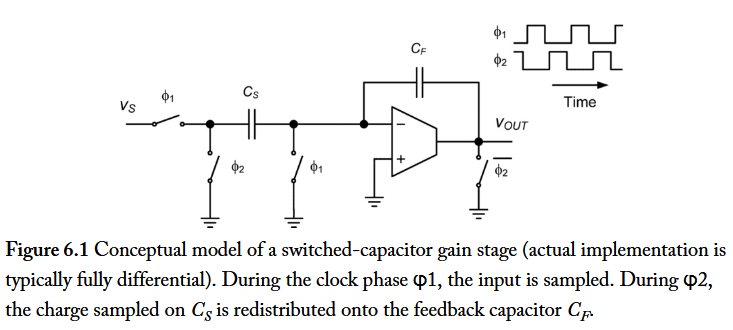 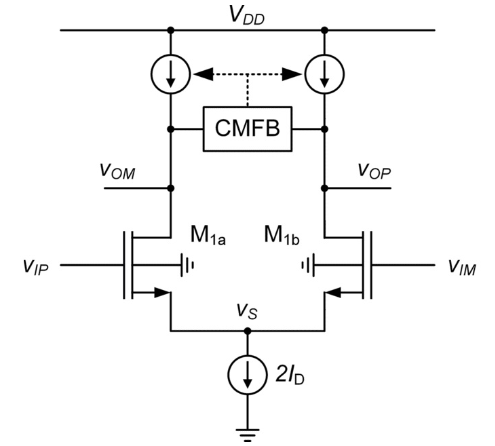 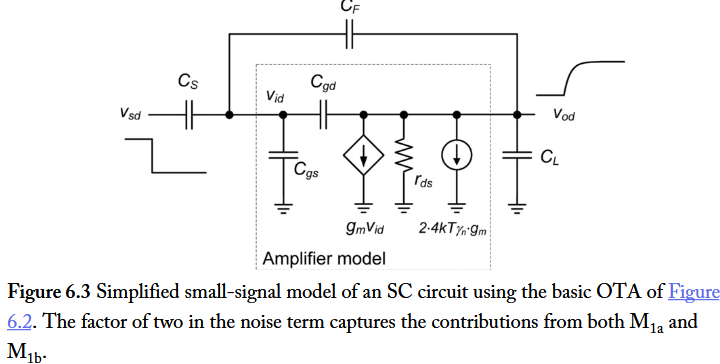

##### Formulas  
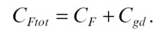 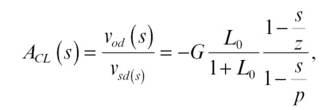 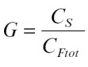 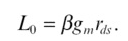 
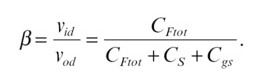 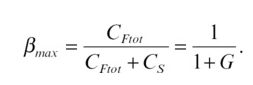  
 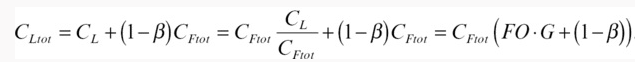  
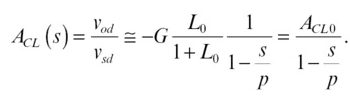 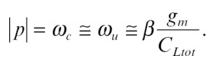 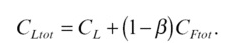 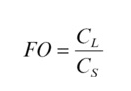  
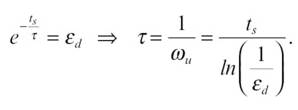 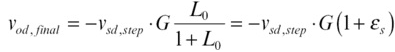 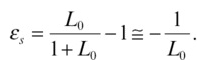 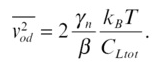  
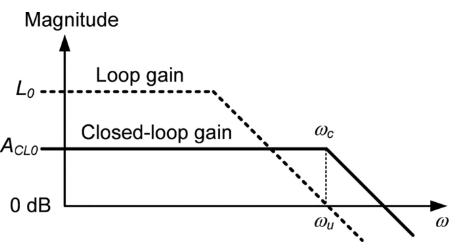

In [189]:
#Spec
VDD = 2.7
Vout = VDD-0.3
Iout = 10e-3
Lballast = 0.35
Lpmirror = 0.5
Ln = 0.5

base : 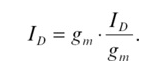 -> Solve this for gm  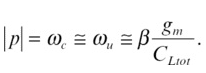  Replace Cltot with 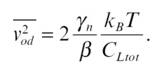  
 => 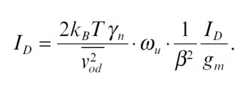 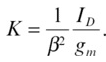  
 Id = F(Noise, bandwidth, beta, gm_id)  
 For set Noise & BW : Minimize K == Maximize Beta &  gm_id  
 **====> PB : More GM_ID == More C_GS == Less Beta**

 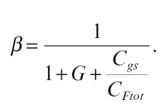 whith 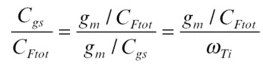 && 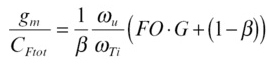 from 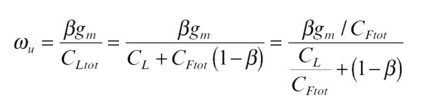 && 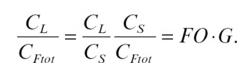  
 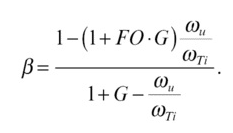
 => 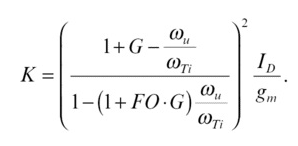  

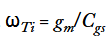 

 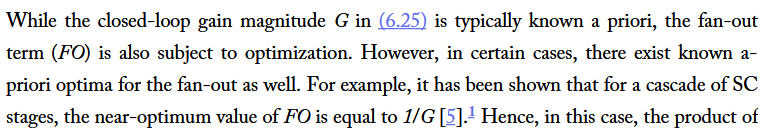  
 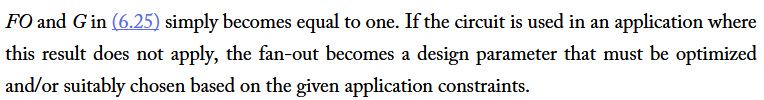  
 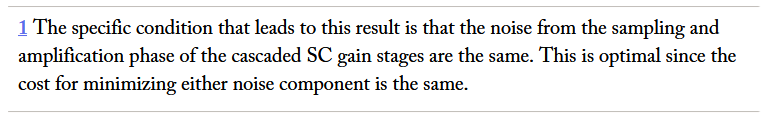

 ### What to do ??  Id = F(Noise, bandwidth, beta, gm_id), if noise & bendwidth are spec,, then Optimize K 

#Exercice Plot  

 for L = 0.1, Fu = 1GHz, G =2, FO = 0.5,1,2,4  
 for L = 0.1, Fu = 1GHz, G = 1,2,4,8, FO.G = 2  
At min current -> plot gm/id ; fti ; ratio b/betamax ; cgs / (cs+Cftot)


For FO = 0.50, the beta_opt_max is 0.91477, at gm_id = 24.14, cgs_cs_cftot = 0.0932, wTi_opt = 0.1989 GHz
For FO = 1.00, the beta_opt_max is 0.88470, at gm_id = 23.26, cgs_cs_cftot = 0.1303, wTi_opt = 0.2346 GHz
For FO = 2.00, the beta_opt_max is 0.83479, at gm_id = 21.80, cgs_cs_cftot = 0.1979, wTi_opt = 0.2858 GHz
For FO = 4.00, the beta_opt_max is 0.78472, at gm_id = 18.28, cgs_cs_cftot = 0.2743, wTi_opt = 0.4059 GHz


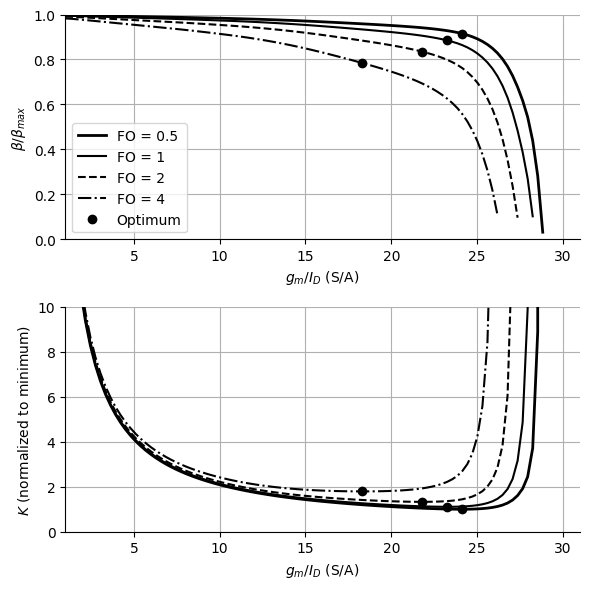

In [190]:
## for L = 0.1, Fu = 1GHz, G =2, FO = 0.5,1,2,4  
####For each FO, compute all beta & K with gm_id from 5 to 25
## Then find the gm_id where K is minimum == min
L = 1
FU = 10e6
G = 2
FO = np.array([0.5, 1, 2, 4])
gm_id = np.linspace(1,30, 100)
wu = 2*np.pi*FU
wTi = nmos4.lookup('GM_CGS', GM_ID = gm_id, L = L)
beta_max = 1 / (1 + G)

##Create array vide  for plots
beta = np.full((len(FO), len(gm_id)),np.nan)
k = np.full((len(FO), len(gm_id)),np.nan)

####For each FO, compute all beta & K with gm_id from 5 to 25
for i in range(len(FO)):
    beta[i, :] = (1-(1+FO[i]*G)*(wu/wTi)) / (1 + G - (wu / wTi))
    beta[beta < 0] = np.nan
    k[i,:] = 1 / beta[i,:] **2 / gm_id

#Normalize et return min K, ixd is the [i] where k is at minimum
k = k / np.nanmin(np.nanmin(k,axis=1))
kmin = np.nanmin(k,axis=1)
idx = np.nanargmin(k, axis=1)

###Param opt
gm_id_opt = gm_id[idx]
wTi_opt = wTi[idx] / (2*np.pi)
beta_opt = np.diag(beta[:,idx])
beta_opt_max = beta_opt / beta_max
cgs_cs_cftot = 1 / beta_opt_max - 1

plt.figure(figsize=(6, 6))

plt.subplot(2, 1, 1)
plt.plot(gm_id, beta[0, :] / beta_max, 'k-', linewidth=2)
plt.plot(gm_id, beta[1, :] / beta_max, 'k-')
plt.plot(gm_id, beta[2, :] / beta_max, 'k--')
plt.plot(gm_id, beta[3, :] / beta_max, 'k-.')
for i in range(len(FO)):
    plt.plot(gm_id[idx[i]], beta_opt_max[i], 'ko')
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$\\beta/\\beta_{max}$')
plt.axis([min(gm_id), max(gm_id) + 1, 0, 1])
plt.legend(['FO = 0.5', 'FO = 1', 'FO = 2', 'FO = 4', 'Optimum'])
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(gm_id, k[0, :], 'k-', linewidth=2)
plt.plot(gm_id, k[1, :], 'k-')
plt.plot(gm_id, k[2, :], 'k--')
plt.plot(gm_id, k[3, :], 'k-.')
for i in range(len(FO)):
    plt.plot(gm_id[idx[i]], kmin[i], 'ko')
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel('$K$ (normalized to minimum)')
plt.axis([min(gm_id), max(gm_id) + 1, 0, 10])
plt.grid(True)

for i in range(len(FO)):
    print('For FO = %.2f, the beta_opt_max is %.5F, at gm_id = %.2F, cgs_cs_cftot = %.4F, wTi_opt = %.4F GHz' % (FO[i], beta_opt_max[i], gm_id_opt[i], cgs_cs_cftot[i], wTi_opt[i]*1e-9))

plt.tight_layout()
plt.show()

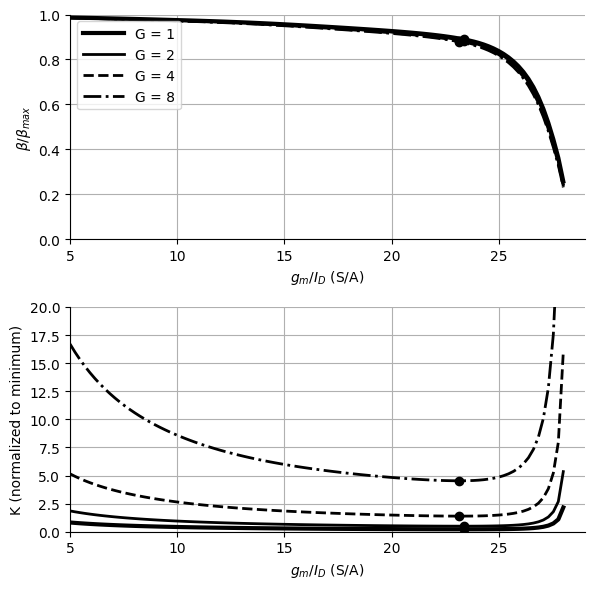

Min K: 0.21649703976814777
Max K: 54.38729581274075
Sample K values: [[ 0.82161006  0.7859067   0.75325308  0.72327335  0.69565004]
 [ 1.85188718  1.77152795  1.69803511  1.63056199  1.56839342]
 [ 5.15139137  4.9281122   4.72391623  4.53644946  4.36372337]
 [16.70619954 15.98264765 15.32094673 14.71346519 14.153756  ]]


In [191]:
#for L = 0.1, Fu = 1GHz, G = 1,2,4,8, FO.G = 2 
#At min current -> plot gm/id ; fti ; ratio b/betamax ; cgs / (cs+Cftot)

L = 1
FU = 10e6
G = np.array([1, 2, 4, 8])
FO = 2 / G
gm_id = np.linspace(5,28, 100)
wu = 2*np.pi*FU
wTi = nmos4.lookup('GM_CGS', GM_ID = gm_id, L = L)
beta_max = 1 / (1 + G)

##Create array vide  for plots
beta = np.full((len(FO), len(gm_id)),np.nan)
k = np.full((len(FO), len(gm_id)),np.nan)

####For each FO, compute all beta & K with gm_id from 5 to 25
for i in range(len(FO)):
    beta[i, :] = (1-(1+FO[i]*G[i])*(wu/wTi)) / (1 + G[i] - (wu / wTi))
    beta[beta < 0] = np.nan
    k[i,:] = 1 / beta[i,:] **2 / gm_id

#Normalize et return min K, ixd is the [i] where k is at minimum
""" k = k / np.nanmin(np.nanmin(k,axis=1))
kmin = np.nanmin(k,axis=1)
idx = np.nanargmin(k, axis=1) """

kmin = np.array([np.nanmin(row) if np.any(~np.isnan(row)) else np.nan for row in k])
idx = np.array([np.nanargmin(row) if np.any(~np.isnan(row)) else -1 for row in k])


###Param opt
gm_id_opt = gm_id[idx]
wTi_opt = wTi[idx] / (2*np.pi)
beta_opt = np.diag(beta[:,idx])
beta_opt_max = beta_opt / beta_max
cgs_cs_cftot = 1 / beta_opt_max - 1

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(6, 6))

linestyles = ['-', '-', '--', '-.']
linewidths = [3, 2, 2, 2]   # to mimic the thick G=1 line
color = 'k'

# First subplot
handles = []
for i in range(len(G)):
    h, = axs[0].plot(
        gm_id, beta[i, :] / beta_max[i],
        linestyle=linestyles[i], linewidth=linewidths[i], color=color
    )
    handles.append(h)
    # keep the optimal-point markers out of the legend
    axs[0].plot(gm_id[idx[i]], beta_opt_max[i], 'ko', label='_nolegend_')

axs[0].set_xlabel(r'$g_m/I_D$ (S/A)')
axs[0].set_ylabel(r'$\beta/\beta_{max}$')
axs[0].set_xlim([np.min(gm_id), np.max(gm_id) + 1])
axs[0].set_ylim([0, 1])
axs[0].grid(True)

# legend with the actual line handles
axs[0].legend(handles, [f'G = {g}' for g in G], loc='best', frameon=True, handlelength=3)

# Second subplot
for i in range(len(G)):
    axs[1].plot(
        gm_id, k[i, :],
        linestyle=linestyles[i], linewidth=linewidths[i], color=color
    )
    axs[1].plot(gm_id[idx[i]], kmin[i], 'ko', label='_nolegend_')

axs[1].set_xlabel(r'$g_m/I_D$ (S/A)')
axs[1].set_ylabel('K (normalized to minimum)')
axs[1].set_xlim([np.min(gm_id), np.max(gm_id) + 1])
axs[1].set_ylim([0, 20])
axs[1].grid(True)

plt.tight_layout()
plt.show()

print("Min K:", np.min(k))
print("Max K:", np.max(k))
print("Sample K values:", k[:, :5])

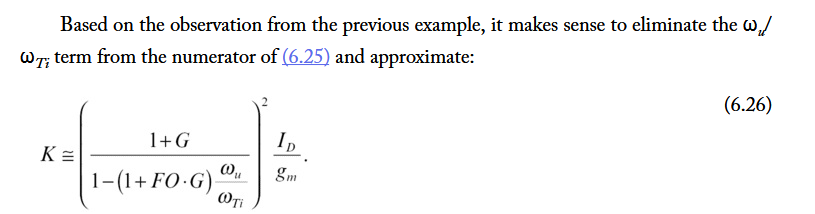  
On voit qu'avec b/betamax == 3/4 on est toujours proche de l'optimal (K minimisé == courant optim)

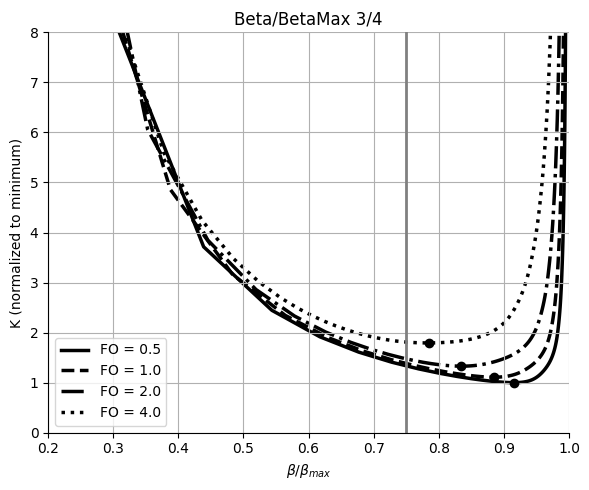

In [192]:
L = 1
FU = 10e6
G = 2
FO = np.array([0.5, 1, 2, 4])
gm_id = np.linspace(1,30, 100)
wu = 2*np.pi*FU
wTi = nmos4.lookup('GM_CGS', GM_ID = gm_id, L = L)
beta_max = 1 / (1 + G)

##Create array vide  for plots
beta = np.full((len(FO), len(gm_id)),np.nan)
k = np.full((len(FO), len(gm_id)),np.nan)

####For each FO, compute all beta & K with gm_id from 5 to 25
for i in range(len(FO)):
    beta[i, :] = (1-(1+FO[i]*G)*(wu/wTi)) / (1 + G - (wu / wTi))
    beta[beta < 0] = np.nan
    k[i,:] = 1 / beta[i,:] **2 / gm_id

#Normalize et return min K, ixd is the [i] where k is at minimum
k = k / np.nanmin(np.nanmin(k,axis=1))
kmin = np.nanmin(k,axis=1)
idx = np.nanargmin(k, axis=1)

###Param opt
gm_id_opt = gm_id[idx]
wTi_opt = wTi[idx] / (2*np.pi)
beta_opt = np.diag(beta[:,idx])
beta_opt_max = beta_opt / beta_max
cgs_cs_cftot = 1 / beta_opt_max - 1


# Plotting

fig, ax = plt.subplots(figsize=(6, 5))


styles = ['k-', 'k--', 'k-.', 'k:']
widths = [2.5, 2.5, 2.5, 2.5]  # thicker lines

for i, fo in enumerate(FO):
    style = styles[i % len(styles)]
    lw = widths[i % len(widths)]
    ax.plot(beta[i, :] / beta_max, k[i, :], style, linewidth=lw, label=f'FO = {fo}', zorder=1)
    ax.plot(beta_opt_max[i], kmin[i], 'ko', markersize=6, zorder=5)

# Reference line
ax.axvline(0.75, color='gray', linewidth=2)

# Labels and formatting
ax.set_xlabel(r'$\beta/\beta_{max}$')
ax.set_ylabel('K (normalized to minimum)')
ax.set_xlim(0.2, 1)
ax.set_ylim(0, 8)
ax.grid(True)
ax.legend(loc='best')
ax.set_title("Beta/BetaMax 3/4")

fig.tight_layout()
plt.show()

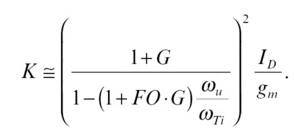  
K_Min quand => 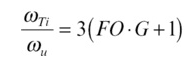 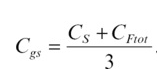 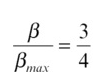

### Sizing of the basic OTA  
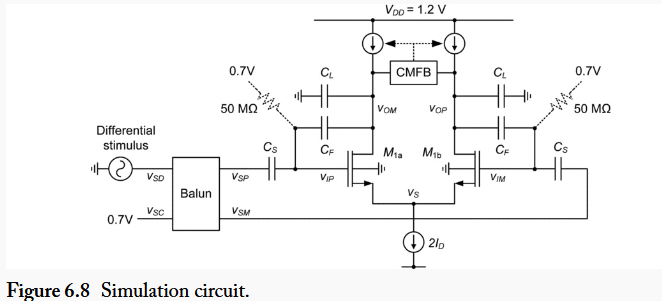

In [193]:
#Spec (find min current)
vnoise_rms = 100e-6
FU = 10e6

#param 
L = 0.5
G = 2
FO = 1

#Find all size, cap, statiuc gain error, settling@0.1%

In [194]:
#From EX1 
#For FO = 1.00, the beta_opt_max is 0.88470, at gm_id = 23.26, cgs_cs_cftot = 0.1303, wTi_opt = 0.2346 GHz
gm_id = 23.26
cgs_cs_cftot = 0.1303
wTi_opt = 0.2346e9
beta_opt_max = 0.88470 #== valeur opti de beta/betamax

#Compute beta
betamax = 1 / (1+G)
beta = beta_opt_max * betamax

 #Compute CL_tot with noise
gamma = 0.7
kbt = 1.3806488e-23*300
cltot = 2 * gamma * kbt / (beta * vnoise_rms**2)

#compute gm from FU and cltot
gm = FU*2*3.14159*cltot/beta

#Compute Id
id = gm / gm_id
#Compute W 
jd = nmos4.lookup('ID_W', GM_ID = gm_id, L = L)
wnmos = id / jd

#Compute caps cltot is known, CF & CS to compute
cftot = cltot / (FO * G + (1-beta))
cs = cftot * G
cl = cs * FO

#Static gain error
gm_gds = nmos4.lookup('GM_GDS', GM_ID = gm_id, L=L)
static_error = - 1 / (beta * gm_gds)

#settling time
ts = np.log(1 / (0.1/100)) / (FU*2*3.14159)

#Cgd for more accuracy with cf
cgd = wnmos * nmos4.lookup('CGD_W', GM_ID = gm_id, L= L)
cf = cftot - cgd

#Csb for more accuracy
cdb = wnmos * nmos4.lookup('CDD_W', GM_ID = gm_id, L= L) - cgd
better_noise_est = np.sqrt(2*0.68/beta * kbt/(cltot+cdb))



print('L  = %.2f, w %.5F, gm_id = %.2F, cftot = %.4F, cs = %.4F, cltot = %.4F, cf = %.4F' % (L, wnmos, gm_id, cftot*1e12, cs*1e12, cltot*1e12, cf*1e12))
print('ts  = %.4f us, id %.5F, vnoise_rms = %.2F, G = %.4F, static_error = %.4F pct' % (ts*1e6, id*1e6, vnoise_rms*1e6, G, static_error*100))
print('better_noise_est  = %.2f uVrms' % (better_noise_est*1e6))


L  = 0.50, w 112.75814, gm_id = 23.26, cftot = 0.7269, cs = 1.4538, cltot = 1.9663, cf = 0.6891
ts  = 0.1099 us, id 18.01162, vnoise_rms = 100.00, G = 2.0000, static_error = -1.9945 pct
better_noise_est  = 94.55 uVrms


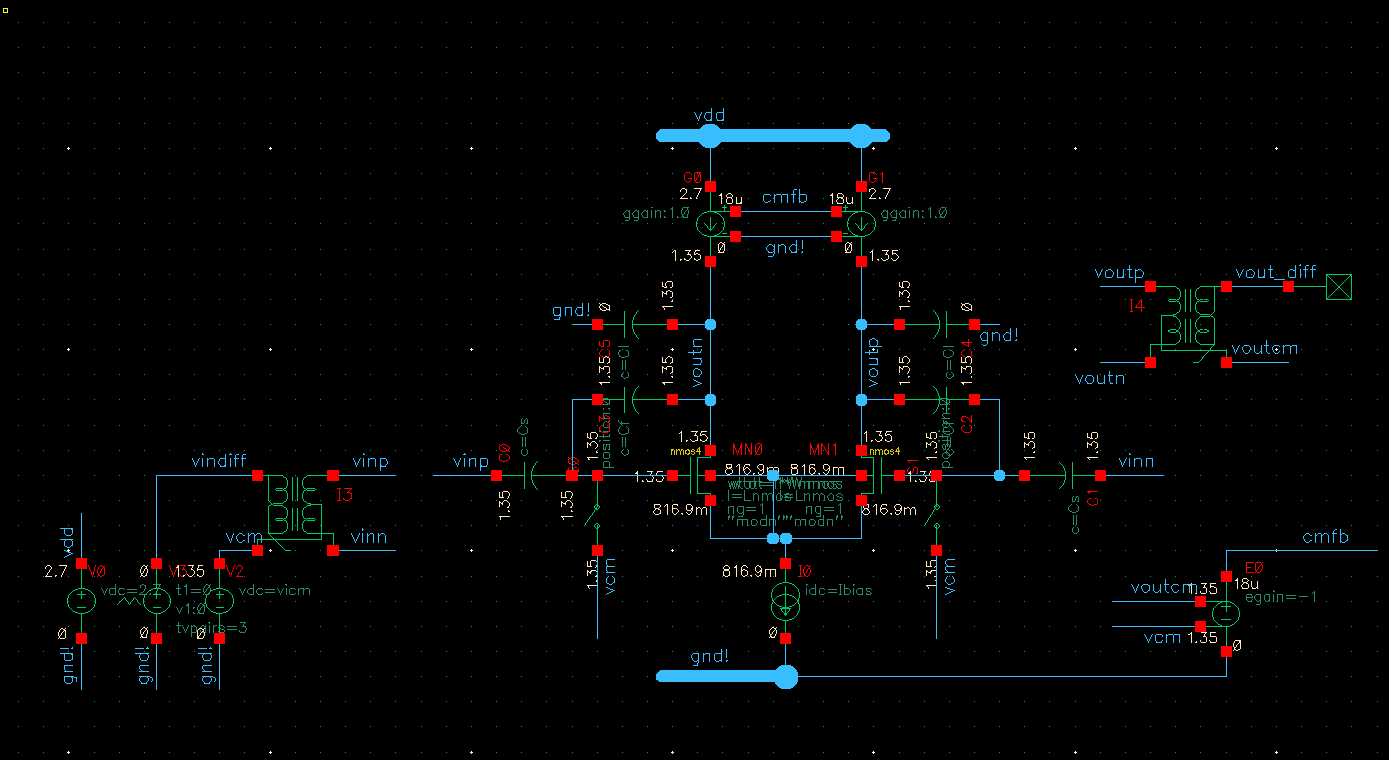  
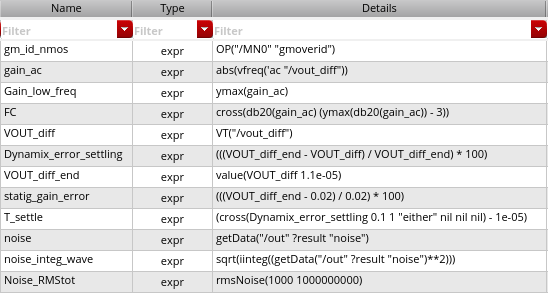 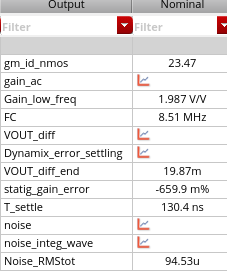

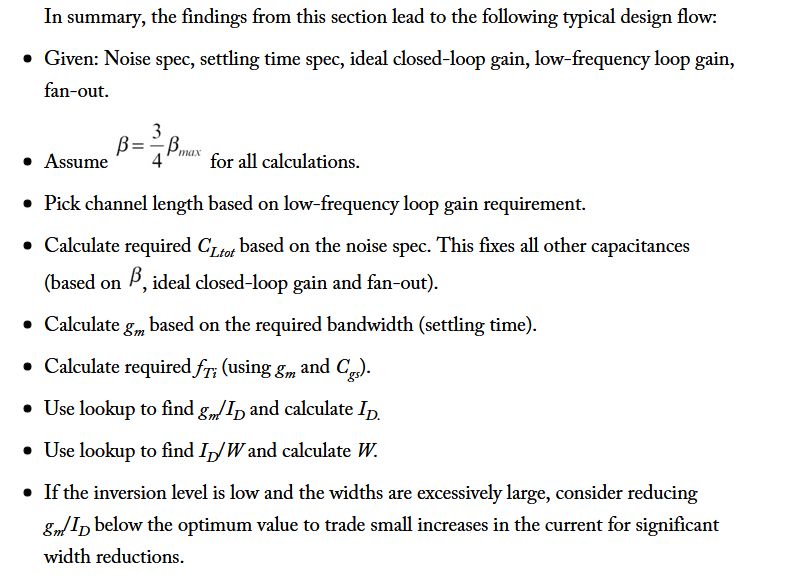

## Considering slew rate

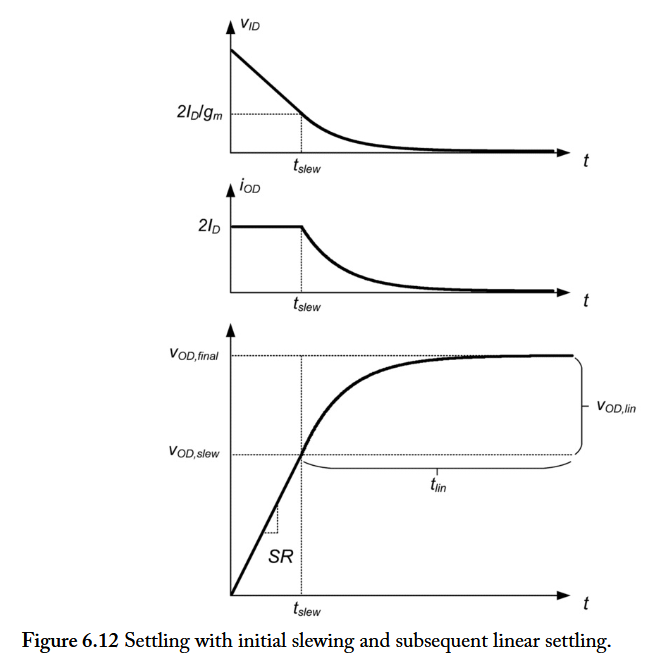 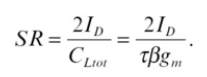 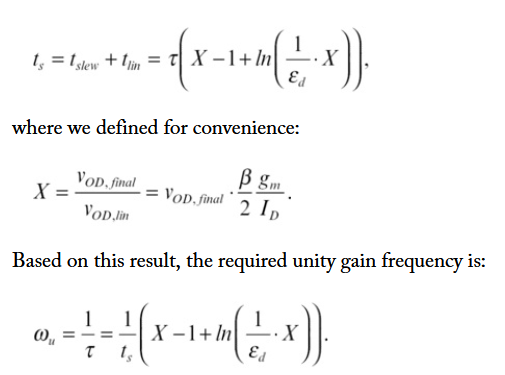  
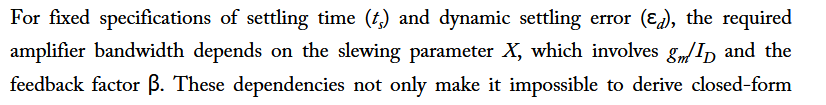  
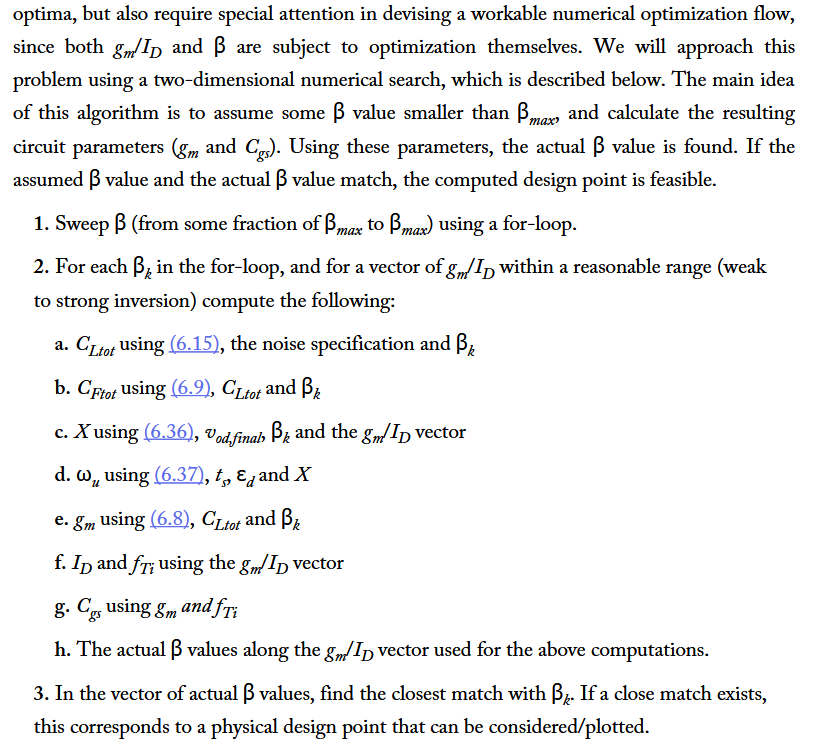

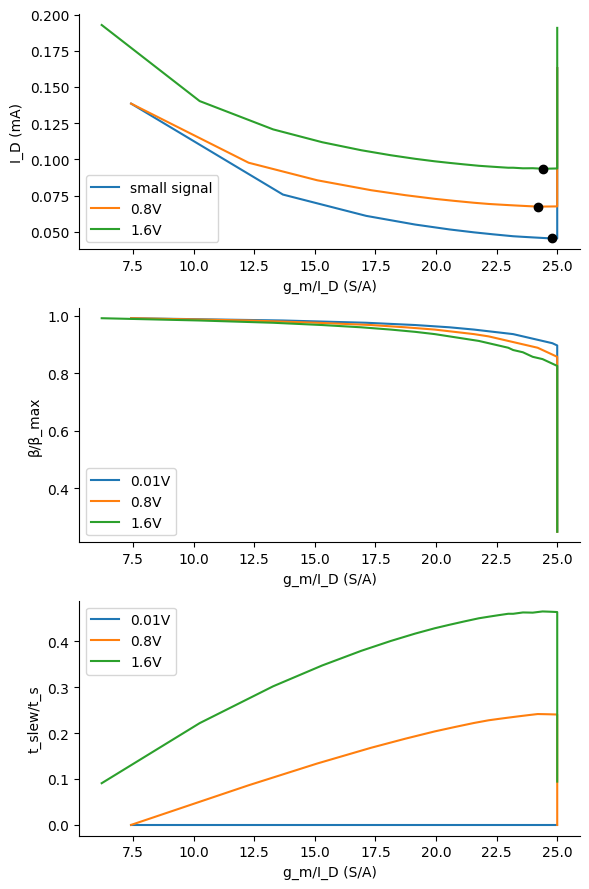

In [195]:
## Optimization with slewing and beta looping
#spec
kB = 1.3806488e-23
T = 300
gamma = 0.7
vod_noise = 100e-6
G = 2
FO = 1
CL_CFtot = G * FO
ed = 0.1 / 100 #erreur settling
ts = 40e-9
beta_max = 1 / (1 + G)
L = 0.35

#search param
vodfinal = [10e-3, .8, 1.6]
gm_ID = np.linspace(5, 25, 100)
beta = np.linspace( 0.25 * beta_max, beta_max +0.01, 100)
beta_rel = beta / beta_max

#init array
ID_valid = np.full((len(beta),len(vodfinal)), np.nan)
gm_ID_valid = np.full((len(beta),len(vodfinal)), np.nan)
X_valid = np.full((len(beta),len(vodfinal)), np.nan)

wTi = nmos4.look_up('GM_CGS', GM_ID = gm_ID, L=L)

#Compute main loop
for i in range(len(vodfinal)):
    for j, b in enumerate(beta):
        #J == index, b == beta[j]
        CLtot = 2 * gamma * kB * T / (b * vod_noise**2)
        CFtot = CLtot / (FO * G + (1-b))
        X = vodfinal[i] * b/2 * gm_ID
        X[X < 1] = 1

        wu = 1 / ts * (X - 1 + np.log(1 / ed * X))
        gm = wu*cltot/b
        ID = gm / gm_ID

        Cgs = gm / wTi

        beta_actual = CFtot / (CFtot + G * CFtot + Cgs)

        ###Interpolate to find self consistent point
        ## Find if a beta_actual match beta[j]
        interp_func = interp1d(beta_actual, np.arange(len(beta_actual)), kind='nearest', fill_value='extrapolate')
        m = int(interp_func(b))
        # print('***')
        # print(b)
        # print(beta_actual)
        # print(np.arange(len(beta_actual)))
        # print(int(interp_func(b)))
        # print('***')
        if m:
            gm_ID_valid[j, i] = gm_ID[m]
            ID_valid[j, i] = ID[m]
            X_valid [j, i] = X[m]

#Min ID calc
ID_min = np.nanmin(ID_valid, axis=0)
idx = np.nanargmin(ID_valid, axis=0)

gm_ID_opt = gm_ID_valid[idx, np.arange(len(vodfinal))]
###Tslew / Ttot
slew_pct = (X_valid - 1) / (X_valid - 1 - np.log(ed * X_valid))

# Plotting
fig, axs = plt.subplots(3, 1, figsize=(6, 9))

# 1st subplot
for i, label in enumerate(['small signal', '0.8V', '1.6V']):
    axs[0].plot(gm_ID_valid[:, i], ID_valid[:, i] * 1e3, label=label)
    axs[0].plot(gm_ID_opt[i], ID_min[i] * 1e3, 'ko')
axs[0].set_xlabel('g_m/I_D (S/A)')
axs[0].set_ylabel('I_D (mA)')
axs[0].legend()
axs[0].grid()

# 2nd subplot
for i in range(len(vodfinal)):
    axs[1].plot(gm_ID_valid[:, i], beta_rel, label=f'{vodfinal[i]}V')
axs[1].set_xlabel('g_m/I_D (S/A)')
axs[1].set_ylabel('β/β_max')
axs[1].legend()
axs[1].grid()

# 3rd subplot
for i in range(len(vodfinal)):
    axs[2].plot(gm_ID_valid[:, i], slew_pct[:, i], label=f'{vodfinal[i]}V')
axs[2].set_xlabel('g_m/I_D (S/A)')
axs[2].set_ylabel('t_slew/t_s')
axs[2].legend()
axs[2].grid()

plt.tight_layout()
plt.show()



In [ ]:
#Param selection -> gm_id & beta & ID & vodfinal
#print('For vod = ', vodfinal[1])

gm_ID_selected = gm_ID_opt[1]  # Corresponds to the second vodfinal condition
beta_selected = beta[idx[1]]  # Selected beta for the design
ID_selected = ID_min[1]  # Selected ID for the design
vodfinal_selected = vodfinal[1]  # Second value in vodfinal

#Design parameter extraction
CLtot = 2 * gamma * kB * T / (beta_selected * vod_noise**2)
gm = ID_selected / gm_ID_selected
JD = nmos4.lookup('ID_W', GM_ID = gm_ID_selected, L=L)
W = ID_selected / JD
Cgd = W * nmos4.lookup('CGD_W', GM_ID = gm_ID_selected, L=L)
Cdb = W * nmos4.lookup('CDD_W', GM_ID = gm_ID_selected, L=L) - Cgd
CFtot = CLtot / (FO * G + (1-beta_selected))
CS = CFtot * G
CL = CS * FO
CF = CFtot - Cgd

##timing
SR = 2 * ID_selected / CLtot
tau = CLtot / (gm * beta_selected)
vodlin = 2 / gm_ID_selected / beta_selected
tslew = tau * (vodfinal_selected / vodlin - 1)

print("-" * 55)
print(f"{'PARAMÈTRE':<38} | {'VALEUR':<12}")
print("-" * 55)

# Paramètres de design
print(f"{'G gain close loop':<38} | {G:>12.2f}")
print(f"{'Inversion level (gm/ID)':<38} | {gm_ID_selected:>12.2f}")
print(f"{'Beta for design':<38} | {beta_selected:>12.4f}")
print(f"{'Drain current ID (µA)':<38} | {ID_selected * 1e6:>12.2f}")
print(f"{'Final Vod (V)':<38} | {vodfinal_selected:>12.2f}")
print(f"{'Linear region voltage Vodlin (V)':<38} | {vodlin:>12.2f}")

print("-" * 55)
# Dimensions et Transconductance
print(f"{'Total width W (µm)':<38} | {W:>12.2f}")
print(f"{'Total Length L (µm)':<38} | {L:>12.2f}")
print(f"{'Transconductance gm (µS)':<38} | {gm * 1e6:>12.2f}")

print("-" * 55)
# Capacités (converties en pF pour la lisibilité)
print(f"{'Total load CLtot (pF)':<38} | {CLtot * 1e12:>12.3f}")
print(f"{'Load capacitance CL (pF)':<38} | {CL * 1e12:>12.3f}")
print(f"{'Total feedback CFtot (pF)':<38} | {CFtot * 1e12:>12.3f}")
print(f"{'Feedback capacitance CF (pF)':<38} | {CF * 1e12:>12.3f}")
print(f"{'CS capacitance (pF)':<38} | {CS * 1e12:>12.3f}")
print(f"{'Gate-drain Cgd (pF)':<38} | {Cgd * 1e12:>12.3f}")
print(f"{'Drain-bulk Cdb (pF)':<38} | {Cdb * 1e12:>12.3f}")

print("-" * 55)
# Temps et Slew Rate
print(f"{'T_integ ts (ns)':<38} | {ts * 1e9:>12.2f}")
print(f"{'Slew rate SR (V/µs)':<38} | {SR / 1e6:>12.2f}")
print(f"{'Time constant tau (ns)':<38} | {tau * 1e9:>12.2f}")
print(f"{'Slew time tslew (µs)':<38} | {tslew * 1e6:>12.3f}")
print("-" * 55)

-------------------------------------------------------
PARAMÈTRE                              | VALEUR      
-------------------------------------------------------
G gain close loop                      |         2.00
Inversion level (gm/ID)                |        24.19
Beta for design                        |       0.2961
Drain current ID (µA)                  |        67.44
Final Vod (V)                          |         0.80
Linear region voltage Vodlin (V)       |         0.28
-------------------------------------------------------
Total width W (µm)                     |       449.29
Total Length L (µm)                    |         0.35
Transconductance gm (µS)               |         2.79
-------------------------------------------------------
Total load CLtot (pF)                  |        1.959
Load capacitance CL (pF)               |        1.449
Total feedback CFtot (pF)              |        0.724
Feedback capacitance CF (pF)           |        0.574
CS capacitance (pF) 

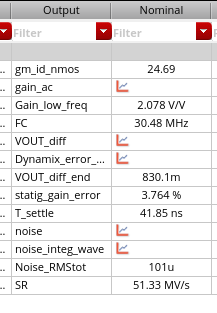

## Possible Simplified flow without all of this  
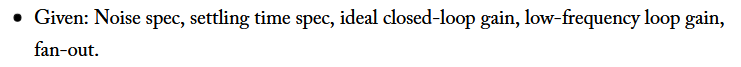  
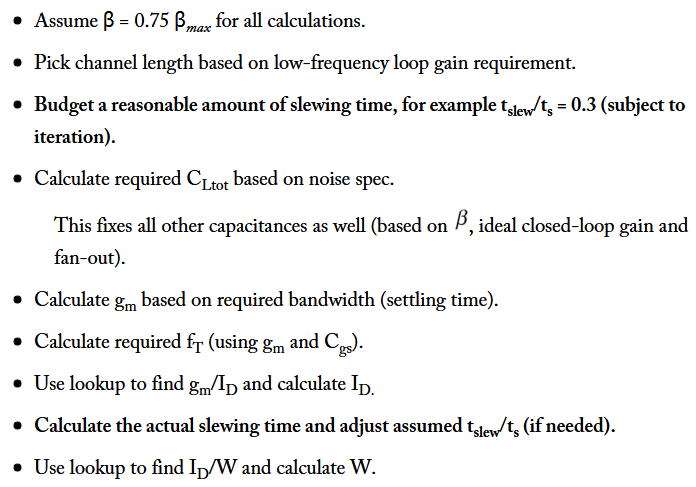
